# Lecture 3: Credible regions and coverage
**Guided student notebook · about 90 minutes**

Start with a complete linear analysis (20 min), adapt it to a nonlinear mean
(20 min), then compare coverage at a fixed truth (20 min) and averaged over the
prior (20 min), with 10 min for discussion.

This tutorial has fewer coding gaps than lectures one and two. Run the worked
linear example first, then use it as a template for the **TODOs**. Most of the
work is interpreting the results. Posterior integration, HPD membership and
plotting are supplied in [lecture_03_helpers.py](lecture_03_helpers.py);
you do not need to study or change their implementation.

References: [lecture-three summary](../handouts/lecture_03_summary.pdf) and
[the lecture's linear/nonlinear comparison](../friedrich_nonlinear_mean_bayesian_coverage.ipynb).

## Setup
Reuse the environment from lecture one. In a terminal at the repository root:

```bash
cd tutorials
source .venv/bin/activate
uv pip install --python .venv -r requirements.txt
python -m jupyterlab
```

For a first installation, install [uv](https://docs.astral.sh/uv/getting-started/installation/)
and run `uv venv --python 3.12` after `cd tutorials`, before activating the environment.
In Windows PowerShell, replace the activation line with `.venv\Scripts\Activate.ps1`.
Select this environment as the notebook kernel and keep `lecture_03_helpers.py`
and `requirements.txt` alongside the notebooks. Restart the kernel after installing packages.

JAX 0.11.1; sample shape: (32,)


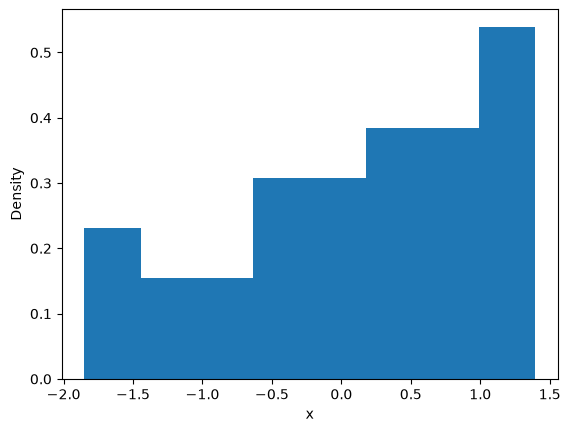

In [1]:
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.special import ndtri
import matplotlib.pyplot as plt

from lecture_03_helpers import (
    posterior_grid, hpd_region, hpd_contains, plot_analysis, plot_coverage,
)

jax.config.update("jax_enable_x64", True)
plt.style.use("default")
key = random.key(303)
sigma = 0.5
prior_bounds = (-10.0, 10.0)
q = 0.683

setup_sample = random.normal(random.key(101), shape=(32,))
print(f"JAX {jax.__version__}; sample shape: {setup_sample.shape}")
plt.hist(setup_sample, bins=8, density=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

## 1. A complete linear analysis · 20 min
Each experiment observes **one two-component data vector** and has one unknown
scalar parameter:
$$\mathbf d\mid\alpha\sim\mathcal N_2(\boldsymbol\mu(\alpha),\sigma^2 I_2),
\qquad \boldsymbol\mu(\alpha)=(\alpha,\alpha),\qquad \sigma=0.5.$$
For inference we use the proper prior $\alpha\sim\operatorname{Uniform}(-10,10)$.
Its density is $1/20$ within the bounds and zero outside.

**Run and read: there are no coding gaps in this section.** The mean function
below works for a single value of alpha or an array: its final axis holds the
two predicted measurements. The likelihood uses the squared residuals in both
components. We omit its normalising constant because it does not depend on alpha.

In [2]:
def linear_mean(alpha):
    return jnp.stack((alpha, alpha), axis=-1)

def linear_log_likelihood(alpha, data):
    residuals = data - linear_mean(alpha)
    return -0.5 * jnp.sum((residuals / sigma)**2, axis=-1)

Simulate one observation at the fixed generating truth `alpha_true = 0`.
Splitting the key gives a fresh noise draw each time this cell runs.
The truth is used to generate and assess data; it is not passed to the posterior calculation.

In [3]:
alpha_true = 0.0
key, draw_key = random.split(key)
example_noise = sigma * random.normal(draw_key, shape=(2,))
linear_data = linear_mean(alpha_true) + example_noise
print("Observed data:", linear_data)

Observed data: [0.77315266 0.36408489]


Bayes' theorem gives
$$p(\alpha\mid\mathbf d)\propto
\exp[\log L(\alpha;\mathbf d)]\,\mathbf1_{[-10,10]}(\alpha).$$
The supplied helper applies the finite prior bounds and normalises this density.
A **68.3% highest-posterior-density (HPD) region** contains the largest density
values, down to a threshold enclosing posterior mass $q=0.683$.
This region rule is used throughout; it is not an equal-tailed interval rule.

The left plot shows how alpha maps into data space. The right shows the posterior
over alpha, with its HPD region shaded. The helper keeps separate HPD pieces if
they occur; it does not fill the gap between them.

Posterior mass in the HPD region: 0.6830


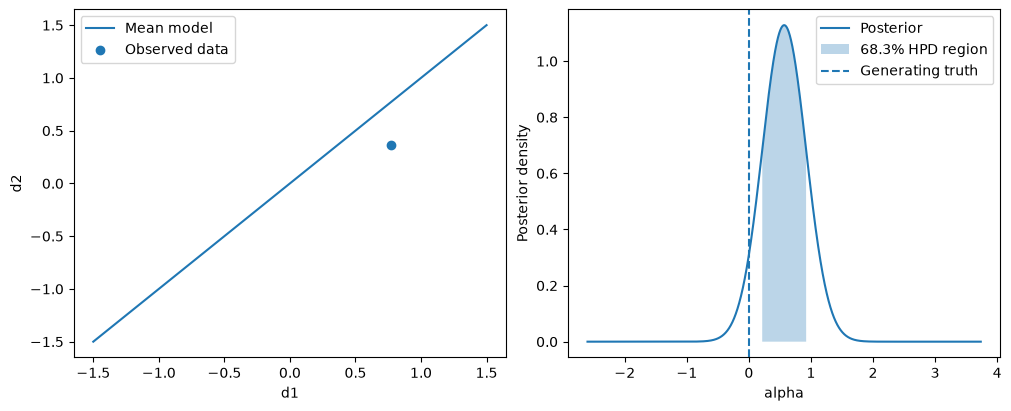

In [4]:
linear_grid, linear_posterior = posterior_grid(
    linear_data, linear_log_likelihood, prior_bounds=prior_bounds,
)
linear_mask, linear_threshold, linear_mass = hpd_region(linear_grid, linear_posterior, level=q)
print(f"Posterior mass in the HPD region: {float(linear_mass):.4f}")
plot_analysis(
    linear_data, linear_mean, linear_grid, linear_posterior, linear_mask, alpha_true, level=q,
)

For this linear model, completing the square gives a Gaussian posterior
truncated to the prior bounds. For this interior example the truncation is negligible:
$$\widehat\alpha=\frac{d_1+d_2}{2},\qquad s=\frac{\sigma}{\sqrt2},\qquad
p(\alpha\mid\mathbf d)\approx\mathcal N(\widehat\alpha,s^2).$$
The supplied **exact Gaussian confidence interval** is
$\widehat\alpha\pm z_qs$, where $z_q=\Phi^{-1}((1+q)/2)$.
Compare its endpoints with the numerical HPD endpoints below.

The confidence interval has exact repeated-experiment coverage $q$ for this model.
The finite-prior HPD region agrees approximately away from the bounds. Exact
endpoint equality would hold with the formal flat prior over the whole real line;
that improper prior cannot be used to draw truths later in this tutorial.

In [5]:
alpha_hat = jnp.mean(linear_data)
posterior_sd = sigma / jnp.sqrt(2.0)
z_q = ndtri((1 + q) / 2)
linear_confidence_interval = alpha_hat + jnp.array([-1.0, 1.0]) * z_q * posterior_sd
linear_hpd_endpoints = linear_grid[linear_mask][jnp.array([0, -1])]
print(f"Gaussian centre: {float(alpha_hat):.4f}; standard deviation: {float(posterior_sd):.4f}")
print("Gaussian confidence interval:", jnp.round(linear_confidence_interval, 4))
print("HPD endpoints on the grid:   ", jnp.round(linear_hpd_endpoints, 4))

Gaussian centre: 0.5686; standard deviation: 0.3536
Gaussian confidence interval: [0.2148 0.9224]
HPD endpoints on the grid:    [0.2164 0.9212]


**Discuss.**

1. What varies, and what is held fixed, in the sampling distribution,
   likelihood and posterior?
2. Why is the posterior width $\sigma/\sqrt2$, rather than $\sigma$?
3. State the two different probability interpretations for these nearly identical intervals.

**Your answer:**

## 2. Change the mean to a nonlinear model · 20 min
Keep the same noise and prior, and change only the mean relation:
$$\boldsymbol\mu(\alpha)=(\alpha,\alpha^3).$$

**Task.** Copy the two worked functions and adapt them below. In `nonlinear_mean`,
change the second component to `alpha**3`. For the log-likelihood, calculate
`residuals = data - nonlinear_mean(alpha)` and use the same sum of squared
residuals as before. Both components still have independent Gaussian noise.

In [6]:
def nonlinear_mean(alpha):
    return None  # TODO: adapt jnp.stack((alpha, alpha), axis=-1).

def nonlinear_log_likelihood(alpha, data):
    return None  # TODO: copy the linear log-likelihood using nonlinear_mean.

Use the same generating truth and noise draw. At alpha = 0 the two models have
the same mean, so they produce exactly the same observed data here. Any posterior
difference comes from the mean relation at other candidate alpha values.
All normalisation, HPD and plotting calls below are the same as in the worked example.

In [7]:
nonlinear_ready = nonlinear_mean(jnp.array(0.0)) is not None
if nonlinear_ready:
    nonlinear_ready = nonlinear_log_likelihood(jnp.array(0.0), linear_data) is not None

if not nonlinear_ready:
    print("Complete the two nonlinear functions, then rerun this cell.")
else:
    nonlinear_data = nonlinear_mean(alpha_true) + example_noise
    nonlinear_grid, nonlinear_posterior = posterior_grid(
        nonlinear_data, nonlinear_log_likelihood, prior_bounds=prior_bounds,
    )
    nonlinear_mask, nonlinear_threshold, nonlinear_mass = hpd_region(
        nonlinear_grid, nonlinear_posterior, level=q,
    )
    print("Observed data:", nonlinear_data)
    print(f"Posterior mass in the HPD region: {float(nonlinear_mass):.4f}")
    plot_analysis(
        nonlinear_data, nonlinear_mean, nonlinear_grid, nonlinear_posterior,
        nonlinear_mask, alpha_true, level=q,
    )

Complete the two nonlinear functions, then rerun this cell.


**Discuss.** Does Gaussian measurement noise force the posterior in alpha to
be Gaussian? Can we obtain the nonlinear HPD region by taking a fixed distance
either side of the best fit? What property defines the region in both analyses?

**Your answer:**

## 3. Coverage at one fixed truth · 20 min
Keep $\alpha_{\mathrm{true}}=0$ and generate $M=5000$ independent datasets.
Analyse each with the same prior and 68.3% HPD rule as before. Record whether the
region contains the fixed truth. The supplied `hpd_contains` returns one Boolean
per experiment and handles posterior integration internally.

The following **complete linear calculation** is your template. Each dataset
still has only two measurements; the $M$ datasets are not pooled into one fit.
The first call may take a few seconds to compile and evaluate the supplied helper.

In [8]:
M = 5000
fixed_truths = jnp.full(M, alpha_true)
key, draw_key = random.split(key)
fixed_noise = sigma * random.normal(draw_key, shape=(M, 2))
linear_fixed_data = linear_mean(fixed_truths) + fixed_noise
linear_fixed_hits = hpd_contains(
    linear_fixed_data, fixed_truths, linear_log_likelihood, level=q, prior_bounds=prior_bounds,
)
linear_fixed_coverage = jnp.mean(linear_fixed_hits)
linear_fixed_se = jnp.sqrt(linear_fixed_coverage * (1 - linear_fixed_coverage) / M)
print(f"Linear, fixed truth: {100 * float(linear_fixed_coverage):.1f}% "
      f"± {100 * float(linear_fixed_se):.1f} percentage points (one Monte Carlo SE)")
print(f"Nominal posterior mass: {100 * q:.1f}%")

Linear, fixed truth: 68.8% ± 0.7 percentage points (one Monte Carlo SE)
Nominal posterior mass: 68.3%


**Task.** Turn the last two calculations into a reusable function, then run
the supplied nonlinear repetition below. For an array of containment indicators,
$$\widehat c=\frac1M\sum_r I_r,\qquad
\widehat{\mathrm{SE}}(\widehat c)=\sqrt{\frac{\widehat c(1-\widehat c)}M}.$$
Use `len(hits)` for the number of repetitions. The standard error describes
uncertainty in the measured coverage, not uncertainty in alpha for one dataset.

In [9]:
def coverage_summary(hits):
    coverage = None        # TODO: fraction of True entries.
    standard_error = None  # TODO: use coverage and len(hits).
    return coverage, standard_error

In [10]:
coverage_results = {"Linear: fixed truth": (linear_fixed_coverage, linear_fixed_se)}
if not nonlinear_ready:
    print("Complete the nonlinear functions and rerun their analysis first.")
else:
    nonlinear_fixed_data = nonlinear_mean(fixed_truths) + fixed_noise
    nonlinear_fixed_hits = hpd_contains(
        nonlinear_fixed_data, fixed_truths, nonlinear_log_likelihood,
        level=q, prior_bounds=prior_bounds,
    )
    nonlinear_fixed_coverage, nonlinear_fixed_se = coverage_summary(nonlinear_fixed_hits)
    if nonlinear_fixed_coverage is None or nonlinear_fixed_se is None:
        print("Complete coverage_summary, then rerun this cell.")
    else:
        coverage_results["Nonlinear: fixed truth"] = (nonlinear_fixed_coverage, nonlinear_fixed_se)
        print(f"Nonlinear, fixed truth: {100 * float(nonlinear_fixed_coverage):.1f}% "
              f"± {100 * float(nonlinear_fixed_se):.1f} percentage points (one Monte Carlo SE)")
        print(f"Nominal posterior mass: {100 * q:.1f}%")

Complete the nonlinear functions and rerun their analysis first.


**Discuss.** Compare both coverage estimates with 68.3%, allowing for Monte Carlo
error. Is a discrepancy necessarily evidence of an incorrect posterior? Would
increasing $M$ force the nonlinear fixed-truth coverage to approach 68.3%?

The lecture reports roughly 61% for this nonlinear model at alpha = 0.
This is a result for this model, prior, truth and HPD rule, not a universal rate.

**Your answer:**

## 4. Coverage averaged over the prior · 20 min
Change what is redrawn between experiments. First draw a truth from the **same
proper prior used for inference**, then draw its data:
$$\alpha^{(r)}\sim\operatorname{Uniform}(-10,10),\qquad
\mathbf d^{(r)}\mid\alpha^{(r)}\sim
\mathcal N_2(\boldsymbol\mu(\alpha^{(r)}),\sigma^2I_2).$$

**Task.** Complete the one-line draw of $M$ truths below. Use `random.uniform`,
`shape=(M,)` and the endpoints in `prior_bounds`. Each dataset must be checked
against **its own** generating truth. Keep the inference prior, noise and HPD
rule unchanged.

Both models use the same array of truths and the same noise draws to aid comparison.
Within each model, the repetitions remain independent. The supplied integration
also handles the much narrower nonlinear posteriors near the prior boundaries.

In [11]:
key, truth_key, noise_key = random.split(key, 3)
prior_truths = None  # TODO: M uniform truths between prior_bounds[0] and prior_bounds[1].
prior_noise = sigma * random.normal(noise_key, shape=(M, 2))

Complete the prior-truth draw, then rerun this cell.


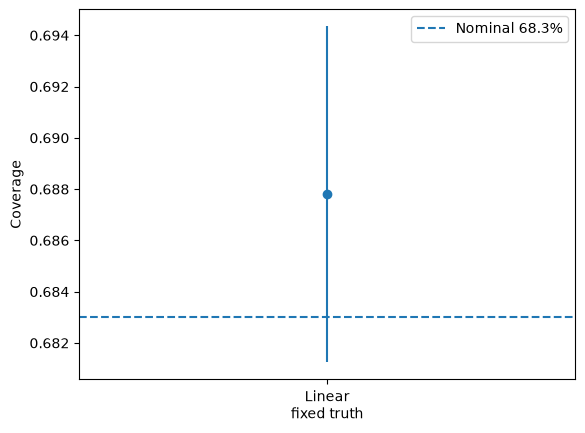

In [12]:
prior_hits = {}
if prior_truths is None:
    print("Complete the prior-truth draw, then rerun this cell.")
else:
    models = [("Linear", linear_mean, linear_log_likelihood)]
    if nonlinear_ready:
        models.append(("Nonlinear", nonlinear_mean, nonlinear_log_likelihood))
    else:
        print("Complete the nonlinear model to include its comparison.")
    for label, mean_model, log_likelihood in models:
        simulated_data = mean_model(prior_truths) + prior_noise
        hits = hpd_contains(
            simulated_data, prior_truths, log_likelihood, level=q, prior_bounds=prior_bounds,
        )
        prior_hits[label] = hits
        coverage, se = coverage_summary(hits)
        if coverage is None or se is None:
            print("Complete coverage_summary, then rerun this cell.")
            break
        coverage_results[f"{label}: prior average"] = (coverage, se)
        print(f"{label}, prior average: {100 * float(coverage):.1f}% "
              f"± {100 * float(se):.1f} percentage points (one Monte Carlo SE)")

plot_coverage(coverage_results, level=q)

**Discuss.** Compare all four results. What changed in the simulation, and what
stayed the same in the analysis? Does nominal coverage averaged over the prior
imply nominal coverage at each fixed alpha? Would the same conclusion be guaranteed
if the truths were drawn from a different prior?

**Your answer:**

## Discussion · 10 min
Finish these three statements precisely:

1. “For these observed data, the HPD region has 68.3% probability” means …
2. “The HPD rule covers alpha = 0 in about 61% of experiments” means …
3. “The HPD rule covers in about 68.3% of prior-drawn experiments” means …

Which statement conditions on observed data, which fixes the truth, and which
averages over truths as well as data? Explain why all three can be correct.

**Your answer:**